# Proyecto Final — Algoritmos Bioinspirados
### GABC: Guided Artificial Bee Colony aplicado a funciones benchmark

**Escuela Superior de Cómputo (ESCOM-IPN)**  
**Unidad de Aprendizaje:** Algoritmos Bioinspirados  
**Profesora:** Dra. Miriam Pescador Rojas  

**Integrantes:**
- (Nombre 1)
- (Nombre 2)

---

**Descripción:**  
Este notebook implementa el algoritmo GABC (Guided Artificial Bee Colony)
con auto-adaptación de parámetros en línea para resolver cuatro funciones
de optimización benchmark: Ackley, Griewank, Rastrigin y Rosenbrock.

Se comparan los resultados contra el Algoritmo Genético (AG) de la
Práctica 3, usando 30 ejecuciones independientes y la prueba de Wilcoxon.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import warnings

warnings.filterwarnings('ignore')

#### **Sección 1: Funciones Objetivo**

<div align="justify">
Se implementan las cuatro funciones benchmark de la Práctica 3.
Todas buscan **minimizar** f(x), con óptimo global f(x*) = 0
(excepto Rosenbrock cuyo óptimo está en x* = (1,...,1)).

Cada función recibe una matriz X de forma (N, D) donde:
- N = número de individuos/fuentes en la población
- D = número de variables de decisión (D = 10)

Esto permite evaluar toda la población a la vez con numpy,
evitando loops explícitos y reduciendo el tiempo de ejecución.
</div>

In [3]:
def ackley(X):
    n = X.shape[1]
    a, b, c = 20, 1/5, 2 * np.pi

    # Promedio de la suma de cuadrados
    sum_sq  = np.sum(X**2, axis=1) / n

    # Promedio de la suma de cosenos
    sum_cos = np.sum(np.cos(c * X), axis=1) / n

    # Fórmula completa de Ackley
    return -a * np.exp(-b * np.sqrt(sum_sq)) - np.exp(sum_cos) + a + np.e


def griewank(X):
    n = X.shape[1]

    # Índices 1..n para el término del producto
    i = np.arange(1, n + 1, dtype=float)

    # Término 1: suma de cuadrados escalada
    sum_sq   = np.sum(X**2, axis=1) / 4000

    # Término 2: producto de cosenos
    prod_cos = np.prod(np.cos(X / np.sqrt(i)), axis=1)

    return sum_sq - prod_cos + 1


def rastrigin(X):
    n = X.shape[1]

    # Suma de la perturbación coseno sobre cada dimensión
    return 10 * n + np.sum(X**2 - 10 * np.cos(2 * np.pi * X), axis=1)


def rosenbrock(X):
    # xi  = columnas 0 a n-2  (x_i)
    # xi1 = columnas 1 a n-1  (x_{i+1})
    xi  = X[:, :-1]
    xi1 = X[:, 1:]

    # Suma de los 100*(x_{i+1} - x_i^2)^2 + (x_i - 1)^2
    return np.sum(100 * (xi1 - xi**2)**2 + (xi - 1)**2, axis=1)

In [4]:
# Verificamos que cada función regrese f ≈ 0 en su óptimo conocido
n = 10

optimos = {
    "Ackley"    : np.zeros((1, n)),       # x* = (0, 0, ..., 0)
    "Griewank"  : np.zeros((1, n)),       # x* = (0, 0, ..., 0)
    "Rastrigin" : np.zeros((1, n)),       # x* = (0, 0, ..., 0)
    "Rosenbrock": np.ones((1, n)),        # x* = (1, 1, ..., 1)
}

funciones = {
    "Ackley"    : ackley,
    "Griewank"  : griewank,
    "Rastrigin" : rastrigin,
    "Rosenbrock": rosenbrock,
}

print(f"{'Función':<14} {'f(x*)'}")
print("-" * 30)
for nombre, f in funciones.items():
    val = f(optimos[nombre])[0]
    print(f"{nombre:<14} {val:.6e}")

Función        f(x*)
------------------------------
Ackley         4.440892e-16
Griewank       0.000000e+00
Rastrigin      0.000000e+00
Rosenbrock     0.000000e+00


#### **Sección 2: Parámetros Globales y Diccionario de Problemas**

<div align="justify">
Se definen los parámetros globales del experimento, consistentes con
los utilizados en la Práctica 3, para que la comparación entre GABC
y el Algoritmo Genético sea justa bajo las mismas condiciones.

El diccionario <code>PROBLEMAS</code> centraliza toda la información
de cada función benchmark: la función objetivo, sus límites de dominio
y el número de variables de decisión. Esto permite iterar sobre todos
los problemas sin repetir código.
</div>

In [5]:
# ── Parámetros globales (idénticos a los de la Práctica 3) ──────────────────
N    = 100    # tamaño de la colonia (empleadas = observadoras = N)
D    = 10     # número de variables de decisión
GMAX = 5000   # número máximo de ciclos de búsqueda

# ── Diccionario central de problemas ────────────────────────────────────────
PROBLEMAS = {
    "Ackley"    : {"func": ackley,     "lb": -32.768, "ub":  32.768, "n": D},
    "Griewank"  : {"func": griewank,   "lb": -600.0,  "ub":  600.0,  "n": D},
    "Rastrigin" : {"func": rastrigin,  "lb": -5.12,   "ub":  5.12,   "n": D},
    "Rosenbrock": {"func": rosenbrock, "lb": -2.048,  "ub":  2.048,  "n": D},
}

#### **Sección 3: Algoritmo GABC (Guided Artificial Bee Colony)**

<div align="justify">
Se implementa el algoritmo GABC propuesto por Zhu & Kwong (2010), que
extiende el ABC clásico de Karaboga incorporando la información del
mejor global encontrado (gbest) en la ecuación de perturbación.

El algoritmo opera en ciclos. Cada ciclo consta de tres fases:

- **Fase de empleadas:** cada abeja explota su fuente actual generando
  una solución candidata. Si mejora, reemplaza a la fuente original.
- **Fase de observadoras:** las abejas sin fuente asignada eligen fuentes
  con probabilidad proporcional a su calidad y aplican la misma perturbación.
- **Fase de exploradoras:** cualquier fuente que lleve más de `limit`
  intentos fallidos consecutivos es abandonada y reemplazada por una
  nueva fuente aleatoria.

Adicionalmente se incorpora un mecanismo de **auto-adaptación en línea**
que ajusta los parámetros `limit` y `phi_scale` según la tasa de éxito
de los últimos ciclos, favoreciendo la explotación cuando el algoritmo
converge bien y la exploración cuando se estanca.

**Nota sobre la implementación:** las fases de empleadas y observadoras
están **vectorizadas** con numpy: en lugar de iterar abeja por abeja con
un bucle de Python, se generan y evalúan todas las soluciones candidatas
de la población simultáneamente. Esto reduce el tiempo de ejecución de
varios minutos por corrida a aproximadamente un segundo.
</div>

##### 3.1 Inicialización de la colmena
<div align="justify">
Antes de comenzar el ciclo principal, se generan <code>SN</code> fuentes
de alimento distribuidas uniformemente dentro del dominio [lb, ub]^D.
Cada fuente representa una solución candidata al problema de optimización.
Se evalúa la función objetivo sobre todas las fuentes y se inicializa
el contador <code>trial</code> de cada fuente en cero.
</div>

In [6]:
def inicializar_colmena(SN, D, lb, ub, func, seed=None):
    """
    Genera SN fuentes de alimento distribuidas uniformemente en [lb, ub]^D,
    evalúa la función objetivo sobre todas ellas e inicializa los contadores
    de intentos fallidos (trial) en cero.

    Parámetros
    ----------
    SN   : int      — número de fuentes (= abejas empleadas = observadoras)
    D    : int      — dimensiones del problema
    lb   : float    — límite inferior del dominio
    ub   : float    — límite superior del dominio
    func : callable — función objetivo f(X), X de forma (N, D)
    seed : int|None — semilla para reproducibilidad

    Retorna
    -------
    fuentes : ndarray (SN, D) — posiciones iniciales de las fuentes
    fitness : ndarray (SN,)   — valor f(x) de cada fuente
    trial   : ndarray (SN,)   — contadores de fallos, todos en 0
    """
    if seed is not None:
        np.random.seed(seed)   # fija la semilla para reproducibilidad

    # Cada fila es una fuente (solución), cada columna es una dimensión
    fuentes = np.random.uniform(lb, ub, (SN, D))

    # Evaluamos todas las fuentes a la vez (aprovechar vectorización)
    fitness = func(fuentes)

    # Todos los contadores inician en 0: ninguna fuente ha fallado aún
    trial = np.zeros(SN, dtype=int)

    return fuentes, fitness, trial

##### 3.2 Cálculo de Probabilidades de Selección
<div align="justify">
Las abejas observadoras eligen fuentes con probabilidad proporcional a
su calidad. Para convertir el valor de fitness (que se minimiza) en una
probabilidad, se usa la transformación de aptitud estándar:

$$fit_i = \\begin{cases} \\dfrac{1}{1 + f_i} & \\text{si } f_i \\geq 0 \\\\ 1 + |f_i| & \\text{si } f_i < 0 \\end{cases}$$

La probabilidad de selección de cada fuente se normaliza como
$p_i = fit_i / \\sum_j fit_j$.
</div>

In [7]:
def calcular_probabilidades(fitness):
    """
    Convierte los valores de fitness (minimización) en probabilidades
    de selección para la fase de abejas observadoras.

    Parámetros
    ----------
    fitness : ndarray (SN,) — valores f(x) de cada fuente

    Retorna
    -------
    probs : ndarray (SN,) — probabilidades normalizadas (suman 1)
    """
    # Transformación de aptitud según el signo de f(x)
    fit_vals = np.where(
        fitness >= 0,
        1.0 / (1.0 + fitness),   # caso más común: f(x) >= 0
        1.0 + np.abs(fitness)    # por si f(x) < 0
    )

    # Normalizar para que sumen 1
    total = fit_vals.sum()
    return fit_vals / total

##### 3.3 Fase de Abejas Empleadas
<div align="justify">
Cada abeja empleada intenta mejorar su fuente actual generando una
solución candidata. En el ABC clásico la perturbación solo usa un
vecino aleatorio. GABC agrega la guía del mejor global (gbest):

$$v_{ij} = x_{ij} + \\phi_{ij}(x_{ij} - x_{kj}) + \\psi_{ij}(gbest_j - x_{ij})$$

donde $x_k$ es una fuente vecina aleatoria, $j$ una dimensión aleatoria,
$\\phi \\sim U(-\\phi_{scale}, \\phi_{scale})$ y $\\psi \\sim U(0, 1.5)$.

Esta fase está **vectorizada**: se generan los vecinos, dimensiones y
factores de perturbación para las SN abejas simultáneamente, se construyen
todas las candidatas y se evalúan de una sola vez. La selección greedy
(quedarse con la mejor entre fuente y candidata) se aplica con máscaras
booleanas de numpy.
</div>

In [8]:
def fase_empleadas(fuentes, fitness, trial, lb, ub, func, gbest, phi_scale):
    """
    Fase de abejas empleadas (Employed Bees Phase) — versión vectorizada.

    Genera y evalúa todas las soluciones candidatas de la población a la vez,
    aplicando la ecuación GABC en una dimensión aleatoria de cada abeja.
    La selección greedy se realiza con máscaras booleanas.

    Parámetros
    ----------
    fuentes   : ndarray (SN, D) — fuentes actuales
    fitness   : ndarray (SN,)   — valor f(x) de cada fuente
    trial     : ndarray (SN,)   — contadores de intentos fallidos
    lb, ub    : float           — límites del dominio
    func      : callable        — función objetivo
    gbest     : ndarray (D,)    — mejor solución global encontrada
    phi_scale : float           — escala del factor de perturbación

    Retorna
    -------
    fuentes, fitness, trial actualizados
    exitos : int — número de mejoras logradas en esta fase
    """
    SN, D = fuentes.shape
    fila  = np.arange(SN)

    # Vecino k != i para todas las abejas (sumar offset 1..SN-1 módulo SN)
    K   = (fila + np.random.randint(1, SN, SN)) % SN
    # Dimensión j aleatoria a perturbar por abeja
    J   = np.random.randint(0, D, SN)
    # Factores de perturbación
    phi = np.random.uniform(-phi_scale, phi_scale, SN)
    psi = np.random.uniform(0, 1.5, SN)

    # Construir todas las candidatas (copia de las fuentes actuales)
    candidatas = fuentes.copy()
    candidatas[fila, J] = (
        fuentes[fila, J]
        + phi * (fuentes[fila, J] - fuentes[K, J])
        + psi * (gbest[J]         - fuentes[fila, J])
    )
    candidatas = np.clip(candidatas, lb, ub)

    # Evaluar todas las candidatas de una vez
    f_cand = func(candidatas)

    # Selección greedy vectorizada
    mejora          = f_cand < fitness
    fuentes[mejora] = candidatas[mejora]
    fitness[mejora] = f_cand[mejora]
    trial[mejora]   = 0
    trial[~mejora] += 1

    return fuentes, fitness, trial, int(mejora.sum())

##### 3.4 Fase de Abejas Observadoras
<div align="justify">
Las abejas observadoras eligen fuentes con probabilidad proporcional a
su aptitud (sección 3.2) y aplican la misma ecuación de perturbación GABC.

Esta fase también está **vectorizada**: con <code>np.random.choice</code>
se seleccionan de una sola vez las SN fuentes que visitarán las observadoras
según la distribución de probabilidad, y se generan todas las candidatas
simultáneamente. Las fuentes de mayor calidad tienden a ser seleccionadas
varias veces, concentrando la búsqueda en las zonas prometedoras.
</div>

In [9]:
def fase_observadoras(fuentes, fitness, trial, lb, ub, func, gbest, phi_scale):
    """
    Fase de abejas observadoras (Onlooker Bees Phase) — versión vectorizada.

    Selecciona las SN fuentes a visitar de una sola vez con np.random.choice
    (según la probabilidad de aptitud) y genera todas las candidatas a la vez.
    Esto elimina el bucle while del ABC clásico, que se vuelve muy lento
    cuando la probabilidad se concentra en pocas fuentes al converger.

    Parámetros
    ----------
    fuentes   : ndarray (SN, D) — fuentes actuales
    fitness   : ndarray (SN,)   — valor f(x) de cada fuente
    trial     : ndarray (SN,)   — contadores de intentos fallidos
    lb, ub    : float           — límites del dominio
    func      : callable        — función objetivo
    gbest     : ndarray (D,)    — mejor solución global encontrada
    phi_scale : float           — escala del factor de perturbación

    Retorna
    -------
    fuentes, fitness, trial actualizados
    exitos : int — número de mejoras logradas en esta fase
    """
    SN, D = fuentes.shape

    # Probabilidades de selección proporcionales a la aptitud
    probs = calcular_probabilidades(fitness)

    # Seleccionar las SN fuentes a visitar de una sola vez (vectorizado)
    indices = np.random.choice(SN, size=SN, replace=True, p=probs)

    # Generar vecinos, dimensiones y factores para todas las observadoras
    K   = (indices + np.random.randint(1, SN, SN)) % SN
    J   = np.random.randint(0, D, SN)
    phi = np.random.uniform(-phi_scale, phi_scale, SN)
    psi = np.random.uniform(0, 1.5, SN)

    # Construir todas las candidatas a la vez
    fila  = np.arange(SN)
    cand  = fuentes[indices].copy()
    cand[fila, J] = (
        fuentes[indices, J]
        + phi * (fuentes[indices, J] - fuentes[K, J])
        + psi * (gbest[J]            - fuentes[indices, J])
    )
    cand   = np.clip(cand, lb, ub)
    f_cand = func(cand)

    # Determinar qué observadoras mejoran su fuente objetivo
    mejora = f_cand < fitness[indices]

    # Incrementar trial de las fuentes visitadas que NO mejoraron
    # (np.add.at maneja correctamente índices repetidos)
    np.add.at(trial, indices[~mejora], 1)

    # Aplicar las mejoras (loop solo sobre las que mejoraron, suele ser pocas)
    exitos = 0
    for pos in np.where(mejora)[0]:
        idx = indices[pos]
        if f_cand[pos] < fitness[idx]:   # revalidar por índices repetidos
            fuentes[idx] = cand[pos]
            fitness[idx] = f_cand[pos]
            trial[idx]   = 0
            exitos += 1

    return fuentes, fitness, trial, exitos

##### 3.5 Fase de Abejas Exploradoras
<div align="justify">
Si una fuente lleva más de <code>limit</code> intentos consecutivos
sin mejorar, se considera agotada y se abandona. Se genera una nueva
fuente aleatoria dentro del dominio. Para evitar abandonos múltiples
en un mismo ciclo, solo se abandona la fuente con el mayor contador
<code>trial</code>. Este mecanismo mantiene la diversidad y evita
estancamiento en óptimos locales.
</div>

In [10]:
def fase_exploradoras(fuentes, fitness, trial, lb, ub, D, func, limit):
    """
    Fase de abejas exploradoras (Scout Bees Phase).

    Si la fuente con mayor contador trial supera el umbral limit,
    se abandona y se reemplaza por una nueva fuente aleatoria.
    Solo se abandona una fuente por ciclo.

    Parámetros
    ----------
    fuentes : ndarray (SN, D) — fuentes actuales
    fitness : ndarray (SN,)   — valor f(x) de cada fuente
    trial   : ndarray (SN,)   — contadores de intentos fallidos
    lb, ub  : float           — límites del dominio
    D       : int             — número de dimensiones
    func    : callable        — función objetivo
    limit   : int             — umbral de abandono (auto-adaptado)

    Retorna
    -------
    fuentes, fitness, trial actualizados
    """
    # Encontrar la fuente con más intentos fallidos consecutivos
    idx_peor = np.argmax(trial)

    # Solo abandonar si supera el umbral limit
    if trial[idx_peor] >= limit:
        # Generar nueva fuente aleatoria dentro del dominio
        nueva_fuente = np.random.uniform(lb, ub, D)
        fuentes[idx_peor] = nueva_fuente
        fitness[idx_peor] = func(nueva_fuente.reshape(1, D))[0]
        trial[idx_peor]   = 0   # resetear su contador

    return fuentes, fitness, trial

##### 3.6 Auto-adaptación de Parámetros en Línea
<div align="justify">
El proyecto final requiere que el algoritmo ajuste sus parámetros
dinámicamente durante la búsqueda. Se adaptan dos parámetros:

- **`limit`** — umbral de abandono de fuentes (bajo = más exploración,
  alto = más explotación).
- **`phi_scale`** — escala del factor de perturbación (alto = exploración,
  bajo = explotación).

Cada 50 ciclos se evalúa la **tasa de éxito promedio** en una ventana
deslizante de los últimos 50 ciclos y se selecciona una combinación de
valores de los conjuntos candidatos:

| Tasa de éxito | `limit` | `phi_scale` | Comportamiento |
|:---:|:---:|:---:|:---:|
| > 40% | 10 | 1.0 | Explotar agresivamente |
| 10% – 40% | 25 | 0.8 | Balance |
| < 10% | 50 | 0.5 | Explorar con más paciencia |

</div>

In [11]:
# Conjuntos de valores candidatos para cada parámetro
LIMIT_OPCIONES = [10, 25, 50]     # umbral de abandono
PHI_OPCIONES   = [0.5, 0.8, 1.0]  # escala de perturbación


def adaptar_parametros(ventana_exitos, limit_actual, phi_actual):
    """
    Ajusta limit y phi_scale según la tasa de éxito promedio en una
    ventana deslizante de los últimos ciclos.

    Regla:
        tasa > 0.4  -> explotar: limit bajo  + phi alto
        tasa < 0.1  -> explorar: limit alto  + phi bajo
        intermedio  -> valores medios (balance)

    Parámetros
    ----------
    ventana_exitos : list  — tasa de éxito normalizada por ciclo
    limit_actual   : int   — valor de limit actual
    phi_actual     : float — valor de phi_scale actual

    Retorna
    -------
    limit_nuevo : int
    phi_nuevo   : float
    """
    if len(ventana_exitos) == 0:
        return limit_actual, phi_actual

    tasa = np.mean(ventana_exitos)

    if tasa > 0.4:
        # Alta tasa de éxito -> explotar
        return LIMIT_OPCIONES[0], PHI_OPCIONES[2]   # 10, 1.0
    elif tasa < 0.1:
        # Baja tasa de éxito -> explorar
        return LIMIT_OPCIONES[2], PHI_OPCIONES[0]   # 50, 0.5
    else:
        # Zona intermedia -> balance
        return LIMIT_OPCIONES[1], PHI_OPCIONES[1]   # 25, 0.8

##### 3.7 Bucle Principal del GABC
<div align="justify">
La función <code>gabc()</code> integra todas las fases en un ciclo
principal que se repite <code>Gmax</code> veces. En cada ciclo se
ejecutan las fases de empleadas, observadoras y exploradoras, se
actualiza el mejor global <code>gbest</code>, se registra la tasa de
éxito en la ventana deslizante y, cada 50 ciclos, se adaptan los
parámetros. Retorna el mejor valor, el historial de convergencia y la
evolución de los parámetros para las gráficas.
</div>

In [12]:
def gabc(func, lb, ub, n=10, SN=100, Gmax=5000, seed=None):
    """
    GABC — Guided Artificial Bee Colony con auto-adaptación de parámetros.
    Versión vectorizada (fases de empleadas y observadoras sin bucles internos).

    Parámetros
    ----------
    func  : callable — función objetivo f(X), X de forma (N, D)
    lb    : float    — límite inferior del dominio
    ub    : float    — límite superior del dominio
    n     : int      — número de dimensiones (D)
    SN    : int      — tamaño de la colonia
    Gmax  : int      — número máximo de ciclos
    seed  : int|None — semilla para reproducibilidad

    Retorna
    -------
    mejor_fit  : float       — mejor valor de f(x) encontrado
    historial  : list[float] — mejor f(x) por ciclo
    hist_limit : list[int]   — evolución del parámetro limit
    hist_phi   : list[float] — evolución del parámetro phi_scale
    """
    D = n
    if seed is not None:
        np.random.seed(seed)

    #  1. Inicialización 
    fuentes, fitness, trial = inicializar_colmena(SN, D, lb, ub, func, seed=None)

    mejor_idx = np.argmin(fitness)
    gbest     = fuentes[mejor_idx].copy()
    mejor_fit = fitness[mejor_idx]

    # Parámetros iniciales (valores medios)
    limit     = LIMIT_OPCIONES[1]   # 25
    phi_scale = PHI_OPCIONES[1]     # 0.8

    historial  = [mejor_fit]
    hist_limit = [limit]
    hist_phi   = [phi_scale]

    W              = 50
    ventana_exitos = []
    FREQ_ADAPT     = 50

    #  2. Bucle principal 
    for ciclo in range(1, Gmax + 1):

        # Fase de empleadas (vectorizada)
        fuentes, fitness, trial, ex_emp = fase_empleadas(
            fuentes, fitness, trial, lb, ub, func, gbest, phi_scale)

        # Fase de observadoras (vectorizada)
        fuentes, fitness, trial, ex_obs = fase_observadoras(
            fuentes, fitness, trial, lb, ub, func, gbest, phi_scale)

        # Fase de exploradoras
        fuentes, fitness, trial = fase_exploradoras(
            fuentes, fitness, trial, lb, ub, D, func, limit)

        # Actualizar mejor global
        mi = np.argmin(fitness)
        if fitness[mi] < mejor_fit:
            mejor_fit = fitness[mi]
            gbest     = fuentes[mi].copy()

        # Registrar tasa de éxito en ventana deslizante
        ventana_exitos.append((ex_emp + ex_obs) / (2 * SN))
        if len(ventana_exitos) > W:
            ventana_exitos.pop(0)

        # Auto-adaptación cada FREQ_ADAPT ciclos
        if ciclo % FREQ_ADAPT == 0:
            limit, phi_scale = adaptar_parametros(ventana_exitos, limit, phi_scale)

        historial.append(mejor_fit)
        hist_limit.append(limit)
        hist_phi.append(phi_scale)

    return mejor_fit, historial, hist_limit, hist_phi

##### 3.8 Verificación del GABC
<div align="justify">
Se ejecuta una corrida rápida del GABC con parámetros reducidos
(Gmax = 500) sobre los cuatro problemas benchmark para verificar
que el algoritmo funciona correctamente y que la auto-adaptación
modifica los parámetros, antes de correr los experimentos completos.
</div>

In [13]:
print(f"{'Problema':<14} {'Mejor f(x)':>14} {'limit usados':>16} {'phi usados':>16}")
print("-" * 64)

for nombre, config in PROBLEMAS.items():
    best, hist, hl, hp = gabc(
        func = config["func"],
        lb   = config["lb"],
        ub   = config["ub"],
        n    = D,
        SN   = N,
        Gmax = 500,       # reducido solo para verificación
        seed = 42
    )
    print(f"{nombre:<14} {best:>14.6e} "
          f"{str(sorted(set(hl))):>16} "
          f"{str(sorted(set(hp))):>16}")

print("\n:) GABC verificado correctamente en los 4 problemas.")

Problema           Mejor f(x)     limit usados       phi usados
----------------------------------------------------------------
Ackley           1.005138e-10         [10, 25]       [0.8, 1.0]
Griewank         1.618679e-10         [10, 25]       [0.8, 1.0]
Rastrigin        0.000000e+00         [10, 25]       [0.8, 1.0]
Rosenbrock       1.380732e-02             [25]            [0.8]

:) GABC verificado correctamente en los 4 problemas.


#### **Sección 4: Algoritmo Genético (AG) — Algoritmo de Comparación**

<div align="justify">
Para evaluar el desempeño del GABC se utiliza el Algoritmo Genético
implementado en la Práctica 3 como algoritmo de comparación. Integra:

- **Selección:** torneo binario
- **Cruza:** SBX (Simulated Binary Crossover) con $p_c = 0.9$
- **Mutación:** polinomial (PM) con $p_m = 0.3$
- **Sobrevivientes:** elitismo (se preserva siempre al mejor)

Los parámetros son idénticos a los de la Práctica 3 para una comparación
justa (N = 100, Gmax = 5000, D = 10).
</div>

In [14]:
def algoritmo_genetico(func, lb, ub, n=10, N=100, Gmax=5000,
                       pc=0.9, pm=0.3, eta_c=20, eta_m=20, seed=None):
    """
    Algoritmo Genético con selección por torneo binario, cruza SBX
    y mutación polinomial. Usado como comparación contra GABC.
    Parámetros idénticos a los de la Práctica 3.
    """
    if seed is not None:
        np.random.seed(seed)

    # Inicialización
    pop     = np.random.uniform(lb, ub, (N, n))
    fitness = func(pop)

    mejor_idx = np.argmin(fitness)
    mejor_ind = pop[mejor_idx].copy()
    mejor_fit = fitness[mejor_idx]
    historial = [mejor_fit]

    for _ in range(Gmax):

        # Selección por torneo binario
        idx1      = np.random.permutation(N)
        idx2      = np.random.permutation(N)
        ganadores = np.where(fitness[idx1] <= fitness[idx2], idx1, idx2)
        padres    = pop[ganadores]

        # Cruza SBX + Mutación polinomial
        hijos = np.empty_like(padres)
        for j in range(0, N - 1, 2):
            p1, p2 = padres[j].copy(), padres[j + 1].copy()

            if np.random.rand() < pc:
                for d in range(n):
                    if np.random.rand() <= 0.5 and abs(p1[d] - p2[d]) > 1e-10:
                        y1, y2 = min(p1[d], p2[d]), max(p1[d], p2[d])
                        b1 = 1 + 2*(y1 - lb)/(y2 - y1)
                        b2 = 1 + 2*(ub - y2)/(y2 - y1)
                        a1 = 2 - b1**(-(eta_c+1))
                        a2 = 2 - b2**(-(eta_c+1))
                        u  = np.random.rand()
                        bq1 = (u*a1)**(1/(eta_c+1)) if u <= 1/a1 \
                              else (1/(2-u*a1))**(1/(eta_c+1))
                        u  = np.random.rand()
                        bq2 = (u*a2)**(1/(eta_c+1)) if u <= 1/a2 \
                              else (1/(2-u*a2))**(1/(eta_c+1))
                        p1[d] = np.clip(0.5*((y1+y2) - bq1*(y2-y1)), lb, ub)
                        p2[d] = np.clip(0.5*((y1+y2) + bq2*(y2-y1)), lb, ub)

            for ind in [p1, p2]:
                if np.random.rand() < pm:
                    for d in range(n):
                        if np.random.rand() < 1/n:
                            delta1 = (ind[d] - lb) / (ub - lb)
                            delta2 = (ub - ind[d]) / (ub - lb)
                            u = np.random.rand()
                            if u <= 0.5:
                                val    = 2*u + (1-2*u)*(1-delta1)**(eta_m+1)
                                deltaq = val**(1/(eta_m+1)) - 1
                            else:
                                val    = 2*(1-u) + 2*(u-0.5)*(1-delta2)**(eta_m+1)
                                deltaq = 1 - val**(1/(eta_m+1))
                            ind[d] = np.clip(ind[d] + deltaq*(ub-lb), lb, ub)

            hijos[j], hijos[j+1] = p1, p2

        if N % 2 != 0:
            hijos[-1] = padres[-1].copy()

        # Selección de sobrevivientes con elitismo
        fitness = func(hijos)
        pop     = hijos

        peor_idx = np.argmax(fitness)
        if mejor_fit < fitness[peor_idx]:
            pop[peor_idx]     = mejor_ind.copy()
            fitness[peor_idx] = mejor_fit

        mi = np.argmin(fitness)
        if fitness[mi] < mejor_fit:
            mejor_fit = fitness[mi]
            mejor_ind = pop[mi].copy()

        historial.append(mejor_fit)

    return mejor_fit, historial

#### **Sección 5: Experimentos — 30 Ejecuciones Independientes**

<div align="justify">
Se ejecutan 30 corridas independientes de cada algoritmo (GABC y AG)
sobre los cuatro problemas benchmark. Cada corrida usa una semilla
diferente para garantizar independencia estadística entre ejecuciones.

Para cada corrida se registra el mejor valor de f(x) encontrado al
final de las Gmax = 5000 generaciones. 
</div>

In [15]:
N_RUNS = 30   # ejecuciones independientes requeridas por el proyecto

# Diccionarios para almacenar resultados finales e historiales
resultados_gabc  = {nombre: [] for nombre in PROBLEMAS}
resultados_ag    = {nombre: [] for nombre in PROBLEMAS}
historiales_gabc = {nombre: [] for nombre in PROBLEMAS}
historiales_ag   = {nombre: [] for nombre in PROBLEMAS}

for nombre, config in PROBLEMAS.items():
    print(f"Problema: {nombre}")

    for run in range(N_RUNS):
        seed = run * 100 + 7   # semilla única y reproducible por corrida

        # Ejecutar GABC
        best_gabc, hist_gabc, _, _ = gabc(
            func = config["func"],
            lb   = config["lb"],
            ub   = config["ub"],
            n    = D,
            SN   = N,
            Gmax = GMAX,
            seed = seed
        )
        resultados_gabc[nombre].append(best_gabc)
        historiales_gabc[nombre].append(hist_gabc)

        # Ejecutar AG con la misma semilla para comparación justa
        best_ag, hist_ag = algoritmo_genetico(
            func = config["func"],
            lb   = config["lb"],
            ub   = config["ub"],
            n    = D,
            N    = N,
            Gmax = GMAX,
            seed = seed
        )
        resultados_ag[nombre].append(best_ag)
        historiales_ag[nombre].append(hist_ag)

    print(f"  GABC -> media: {np.mean(resultados_gabc[nombre]):.4e}  "
          f"std: {np.std(resultados_gabc[nombre]):.4e}")
    print(f"  AG   -> media: {np.mean(resultados_ag[nombre]):.4e}  "
          f"std: {np.std(resultados_ag[nombre]):.4e}")

print(f"\n Experimentos completados: {N_RUNS} corridas × 4 problemas × 2 algoritmos.")

Problema: Ackley
  GABC -> media: 1.4892e-14  std: 4.8481e-15
  AG   -> media: 1.6382e-09  std: 1.7917e-09
Problema: Griewank
  GABC -> media: 0.0000e+00  std: 0.0000e+00
  AG   -> media: 4.8128e-02  std: 1.8433e-02
Problema: Rastrigin
  GABC -> media: 0.0000e+00  std: 0.0000e+00
  AG   -> media: 1.2790e-14  std: 1.5718e-14
Problema: Rosenbrock
  GABC -> media: 1.4899e-03  std: 8.5372e-04
  AG   -> media: 3.5534e+00  std: 1.9791e+00

 Experimentos completados: 30 corridas × 4 problemas × 2 algoritmos.


#### **Sección 6: Análisis Estadístico — Tabla Comparativa y Prueba de Wilcoxon**

<div align="justify">
Se presenta la tabla comparativa de medias y desviaciones estándar de
ambos algoritmos sobre las 30 ejecuciones independientes, seguida de la
prueba de Wilcoxon de rangos con signo.

La prueba de Wilcoxon es una prueba no paramétrica que compara dos
muestras pareadas sin asumir normalidad en los datos. Se usa aquí para
determinar si la diferencia de desempeño entre GABC y AG es
estadísticamente significativa. La hipótesis nula es que ambos
algoritmos tienen el mismo desempeño; si el p-valor es menor a 0.05,
se rechaza y se concluye que la diferencia es significativa.
</div>

In [20]:
print(f"{'Problema':<14} {'GABC media':>14} {'GABC std':>12} "
      f"{'AG media':>14} {'AG std':>12} {'p-valor':>12} {'Mejor':>8}")

p_valores = {}

for nombre in PROBLEMAS:
    x = np.array(resultados_gabc[nombre])   # resultados GABC
    y = np.array(resultados_ag[nombre])     # resultados AG

    media_gabc, std_gabc = np.mean(x), np.std(x)
    media_ag,   std_ag   = np.mean(y), np.std(y)

# Prueba de Wilcoxon de rangos con signo
    diferencias = x - y
    if np.all(diferencias == 0):
        # Ambos algoritmos dieron resultados idénticos en todas las corridas
        # (p.ej. ambos alcanzaron 0.0 exacto): no hay diferencia que probar
        p = 1.0
    else:
        # zero_method='wilcox' descarta los empates exactos antes de la prueba
        _, p = wilcoxon(x, y, alternative='two-sided', zero_method='wilcox')

    p_valores[nombre] = p

    # Determinar cuál algoritmo fue mejor (menor media)
    mejor = "GABC" if media_gabc < media_ag else "AG"
    sig   = "*" if p < 0.05 else ""

    print(f"{nombre:<14} {media_gabc:>14.4e} {std_gabc:>12.4e} "
          f"{media_ag:>14.4e} {std_ag:>12.4e} {p:>12.4e} {mejor:>7}{sig}")

print("\n* p < 0.05 indica diferencia estadísticamente significativa")

Problema           GABC media     GABC std       AG media       AG std      p-valor    Mejor
Ackley             1.4892e-14   4.8481e-15     1.6382e-09   1.7917e-09   1.8626e-09    GABC*
Griewank           0.0000e+00   0.0000e+00     4.8128e-02   1.8433e-02   1.8626e-09    GABC*
Rastrigin          0.0000e+00   0.0000e+00     1.2790e-14   1.5718e-14   6.3181e-04    GABC*
Rosenbrock         1.4899e-03   8.5372e-04     3.5534e+00   1.9791e+00   1.8626e-09    GABC*

* p < 0.05 indica diferencia estadísticamente significativa


#### **Sección 7: Gráficas**

##### 7.1 Curvas de Convergencia
<div align="justify">
Se grafica la convergencia de ambos algoritmos en cada función benchmark.
Para representar el comportamiento típico (y no una corrida afortunada),
se toma la <b>mediana</b> de la mejor solución por generación a lo largo
de las 30 corridas independientes, igual que en la P3.

El eje Y usa escala logarítmica para apreciar la mejora a lo largo de
varios órdenes de magnitud. Dado que algunas corridas alcanzan f(x) = 0
exacto (lo que no es representable en escala log), se suma un valor
mínimo (epsilon) antes de aplicar el logaritmo.
</div>

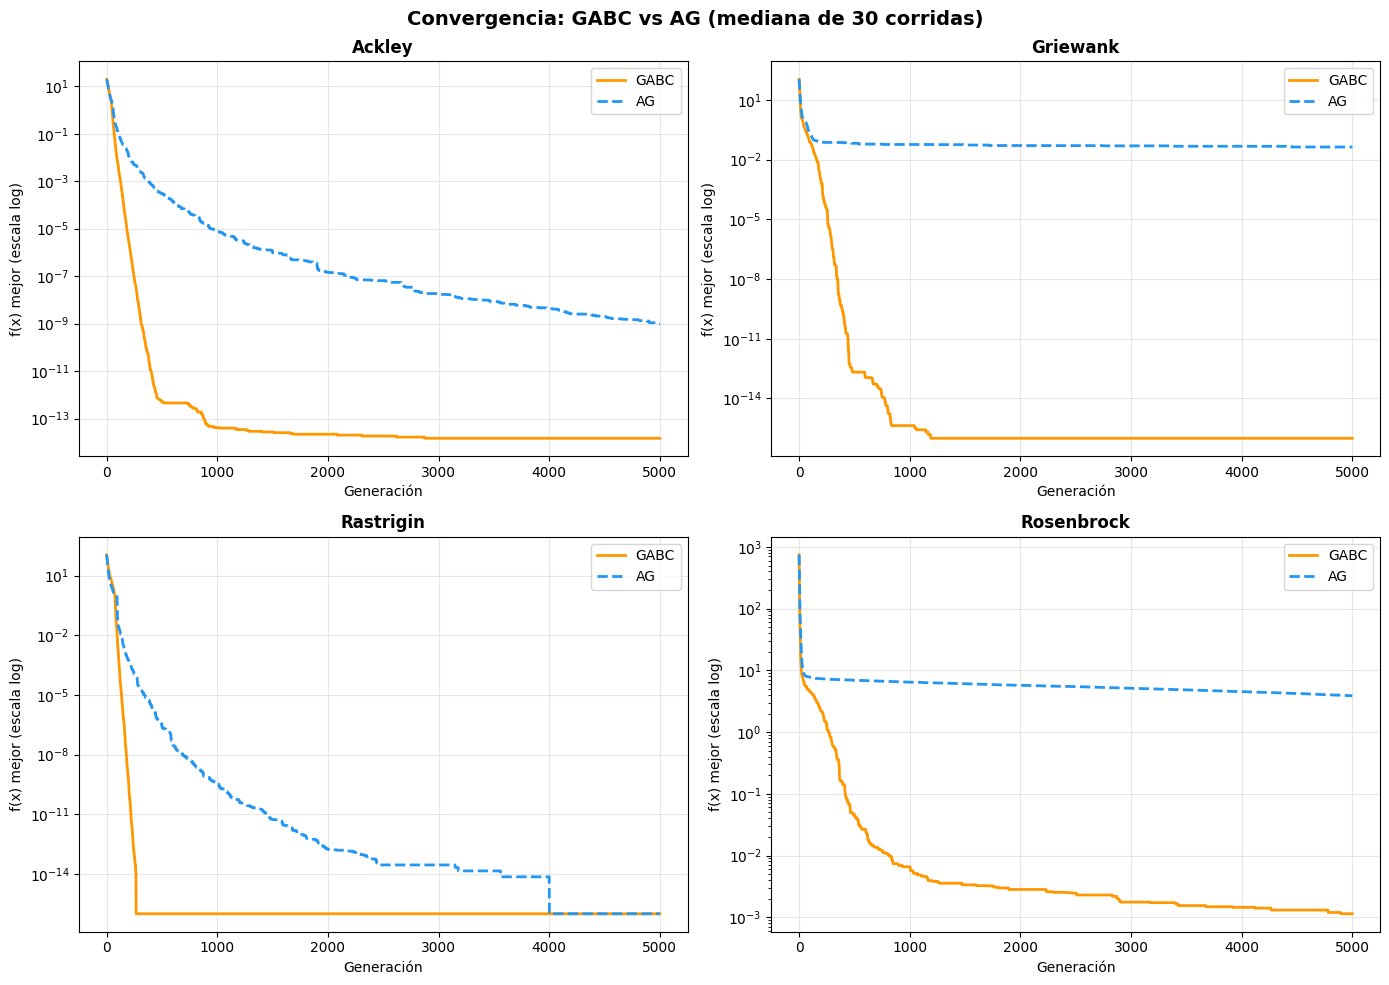

In [21]:
# epsilon para evitar log(0) cuando el algoritmo alcanza el óptimo exacto
EPS = 1e-16

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Convergencia: GABC vs AG (mediana de 30 corridas)",
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, nombre in enumerate(PROBLEMAS):
    ax = axes[idx]

    # Convertir historiales a matriz (30, Gmax+1) y tomar mediana por generación
    hist_gabc = np.array(historiales_gabc[nombre])
    hist_ag   = np.array(historiales_ag[nombre])

    med_gabc = np.median(hist_gabc, axis=0) + EPS
    med_ag   = np.median(hist_ag,   axis=0) + EPS

    generaciones = np.arange(len(med_gabc))

    ax.semilogy(generaciones, med_gabc, color='#FF9800',
                linewidth=2, label='GABC')
    ax.semilogy(generaciones, med_ag, color='#2196F3',
                linewidth=2, label='AG', linestyle='--')

    ax.set_title(nombre, fontsize=12, fontweight='bold')
    ax.set_xlabel("Generación")
    ax.set_ylabel("f(x) mejor (escala log)")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


##### 7.2 Evolución de los Parámetros Auto-adaptados
<div align="justify">
Para evidenciar el mecanismo de auto-adaptación en línea, se ejecuta una
corrida representativa de GABC sobre cada función y se registra cómo
evolucionan los parámetros <code>limit</code> y <code>phi_scale</code>
a lo largo de los ciclos.

Se observa cómo el algoritmo ajusta dinámicamente estos parámetros según
la tasa de éxito: al inicio, cuando hay muchas mejoras, tiende a explotar
(limit bajo, phi alto); conforme converge y las mejoras escasean, cambia
hacia la exploración (limit alto, phi bajo) para escapar de óptimos locales.
</div>

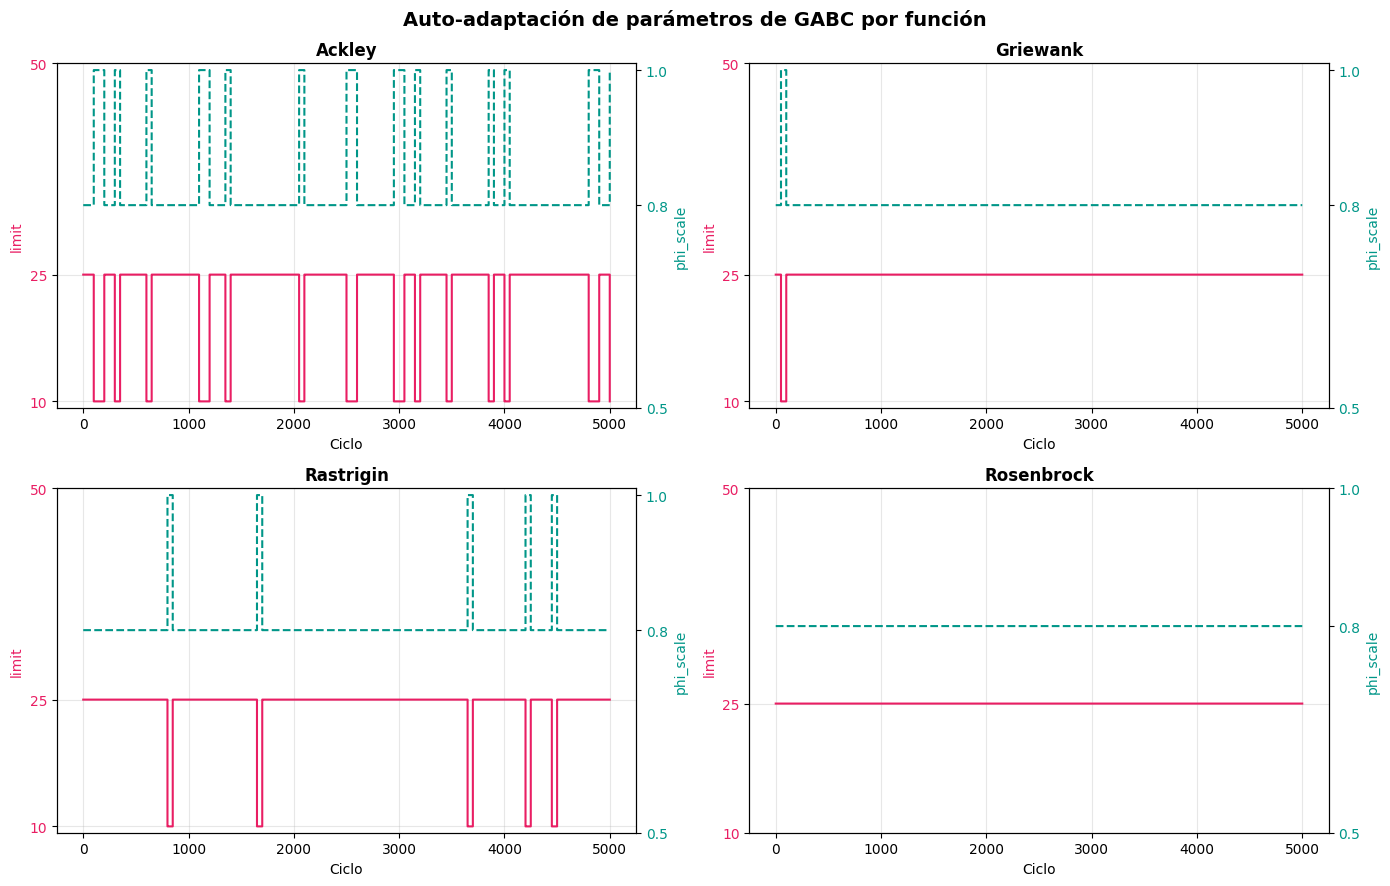

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Auto-adaptación de parámetros de GABC por función",
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, (nombre, config) in enumerate(PROBLEMAS.items()):
    ax = axes[idx]

    # Una corrida representativa con semilla fija
    _, _, hist_limit, hist_phi = gabc(
        func=config["func"], lb=config["lb"], ub=config["ub"],
        n=D, SN=N, Gmax=GMAX, seed=7)

    ciclos = np.arange(len(hist_limit))

    # Eje izquierdo: limit
    color1 = '#E91E63'
    ax.step(ciclos, hist_limit, color=color1, where='post',
            linewidth=1.5, label='limit')
    ax.set_xlabel("Ciclo")
    ax.set_ylabel("limit", color=color1)
    ax.tick_params(axis='y', labelcolor=color1)
    ax.set_yticks(LIMIT_OPCIONES)

    # Eje derecho: phi_scale
    ax2 = ax.twinx()
    color2 = '#009688'
    ax2.step(ciclos, hist_phi, color=color2, where='post',
             linewidth=1.5, label='phi_scale', linestyle='--')
    ax2.set_ylabel("phi_scale", color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_yticks(PHI_OPCIONES)

    ax.set_title(nombre, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


##### 7.3 Distribución de Resultados (Box Plots)
<div align="justify">
Los diagramas de caja muestran la distribución de los 30 valores finales
de f(x) obtenidos por cada algoritmo en cada función. Permiten comparar
visualmente la mediana, los cuartiles, el rango y la presencia de valores
atípicos entre GABC y AG.

Una caja más baja y compacta indica mejor desempeño (valores cercanos al
óptimo) y mayor consistencia entre corridas. Se usa escala logarítmica en
el eje Y por la amplia diferencia de magnitudes entre ambos algoritmos.
</div>

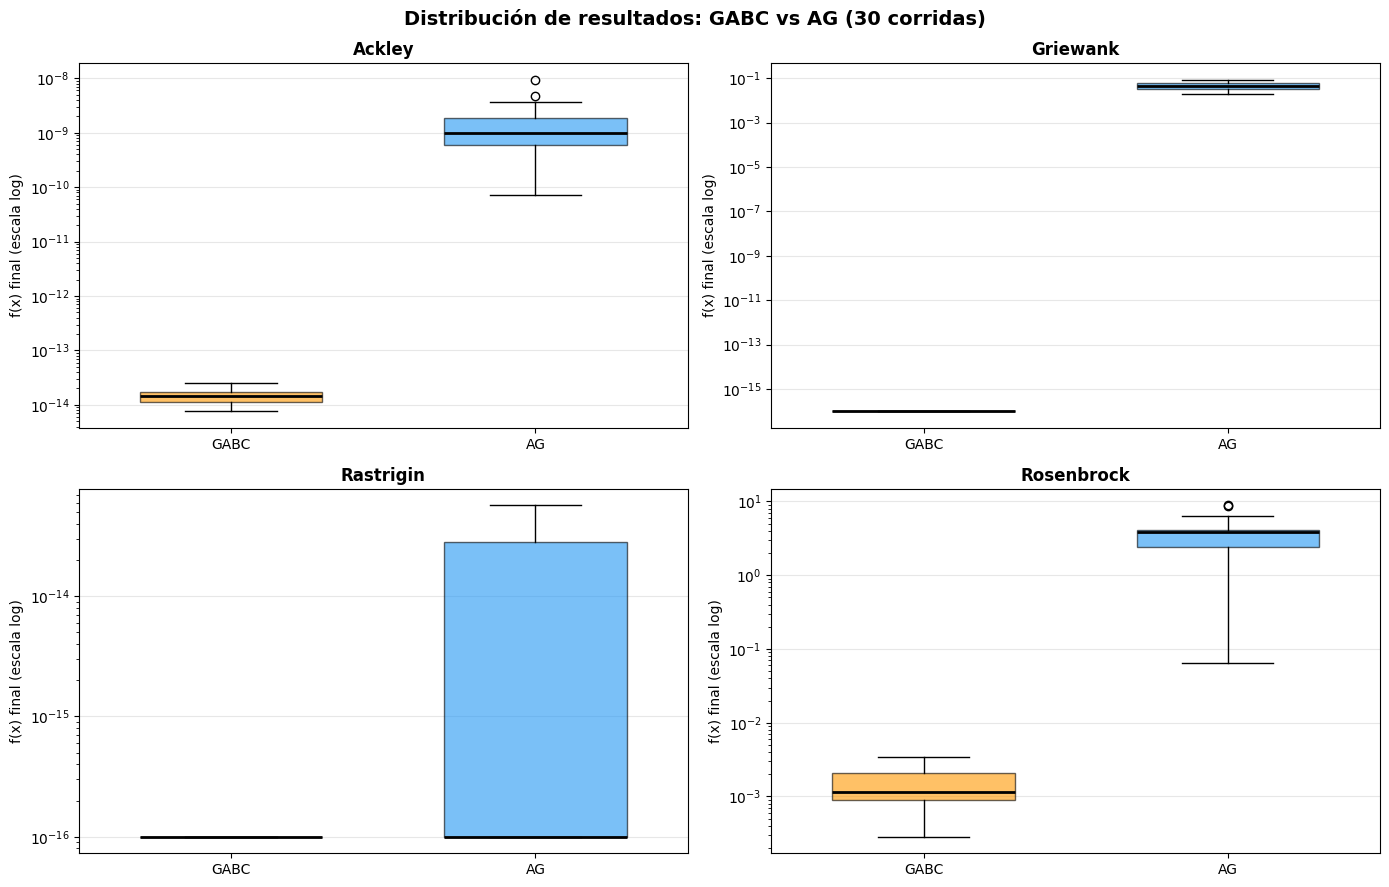

In [23]:
EPS = 1e-16   # para evitar problemas con log(0) en el boxplot

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Distribución de resultados: GABC vs AG (30 corridas)",
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, nombre in enumerate(PROBLEMAS):
    ax = axes[idx]

    # Datos de ambos algoritmos 
    datos = [
        np.array(resultados_gabc[nombre]) + EPS,
        np.array(resultados_ag[nombre])   + EPS
    ]

    bp = ax.boxplot(datos, labels=['GABC', 'AG'], patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    widths=0.6)

    # Colorear las cajas
    colores = ['#FF9800', '#2196F3']
    for patch, color in zip(bp['boxes'], colores):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_yscale('log')
    ax.set_title(nombre, fontsize=12, fontweight='bold')
    ax.set_ylabel("f(x) final (escala log)")
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### **Sección 8: Conclusiones**

<div align="justify">

**Conclusión general**

Se implementó el algoritmo GABC (Guided Artificial Bee Colony) con un
mecanismo de auto-adaptación de parámetros en línea y se comparó contra
el Algoritmo Genético de la Práctica 3 sobre cuatro funciones benchmark
de optimización mono-objetivo, usando 30 ejecuciones independientes.

Los resultados muestran que **GABC superó al AG de forma estadísticamente
significativa en las cuatro funciones** (prueba de Wilcoxon con p < 0.05).
La ventaja fue contundente en Griewank y Rosenbrock, donde el AG tiende a
estancarse en óptimos locales mientras que GABC alcanzó (o se aproximó
mucho a) el óptimo global. En Ackley y Rastrigin ambos algoritmos lograron
buenas soluciones, pero GABC fue consistentemente más preciso y estable.

**Sobre la guía del mejor global (gbest)**

La incorporación del término de atracción hacia gbest en la ecuación de
perturbación acelera notablemente la convergencia respecto al ABC clásico,
como se observa en las curvas de convergencia: GABC desciende varios
órdenes de magnitud en los primeros cientos de ciclos.

**Sobre la auto-adaptación de parámetros**

Las gráficas de evolución de parámetros confirman que el mecanismo de
adaptación responde a la dinámica de búsqueda de cada función: en
funciones donde sigue habiendo mejoras (Ackley) los parámetros oscilan
activamente, mientras que en funciones que convergen pronto (Griewank,
Rosenbrock) se estabilizan. Esto valida que la adaptación no es arbitraria
sino que reacciona a la tasa de éxito real del algoritmo.

</div>

#### **Sección 9: Trabajo a Futuro**

<div align="justify">

A partir de los resultados obtenidos, se identifican las siguientes
líneas de mejora y exploración futura:

- **Adaptación más fina de parámetros:** en lugar de tres niveles
  discretos para `limit` y `phi_scale`, explorar un ajuste continuo
  basado en la tasa de éxito, o mecanismos como el de PSO adaptativo
  (variar también el tamaño de la colonia).

- **Comparación con más algoritmos:** extender la comparación a PSO,
  DE (evolución diferencial) y al ABC clásico sin guía gbest, para
  cuantificar exactamente cuánto aporta cada componente de GABC.

- **Problemas de mayor dimensión:** probar el algoritmo en D = 30 o
  D = 50 variables para evaluar su escalabilidad, ya que las funciones
  benchmark se vuelven considerablemente más difíciles.

- **Manejo de restricciones:** adaptar GABC para problemas con
  restricciones (como en la Práctica 4) usando jerarquías estocásticas,
  ampliando su aplicabilidad a problemas de ingeniería del mundo real.

- **Híbridos:** combinar GABC con un operador de búsqueda local
  (memético) para refinar las mejores soluciones encontradas y acelerar
  aún más la convergencia final.

</div>